In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd

from lightgbm import LGBMRegressor
import lightgbm as lgb

import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

from loguru import logger

RANDOM_STATE = 42

pd.set_option("display.max_columns", None)

In [2]:
!ls ../data/datasets/daily/*

../data/datasets/daily/dataset_level_01_daily_total.parquet
../data/datasets/daily/dataset_level_02_daily_state.parquet
../data/datasets/daily/dataset_level_03_daily_cat.parquet
../data/datasets/daily/dataset_level_04_daily_dept.parquet
../data/datasets/daily/dataset_level_05_daily_state_cat.parquet
../data/datasets/daily/dataset_level_06_daily_store.parquet
../data/datasets/daily/dataset_level_07_daily_state_dept.parquet
../data/datasets/daily/dataset_level_08_daily_store_cat.parquet
../data/datasets/daily/dataset_level_09_daily_store_dept.parquet
../data/datasets/daily/dataset_level_10_daily_item__FOODS_1.parquet
../data/datasets/daily/dataset_level_10_daily_item__FOODS_2.parquet
../data/datasets/daily/dataset_level_10_daily_item__FOODS_3.parquet
../data/datasets/daily/dataset_level_10_daily_item__HOBBIES_1.parquet
../data/datasets/daily/dataset_level_10_daily_item__HOBBIES_2.parquet
../data/datasets/daily/dataset_level_10_daily_item__HOUSEHOLD_1.parquet
../data/datasets/daily/datase

# Data

In [3]:
LEVEL = 'level_09_daily_store_dept'
GRAIN = 'daily'
OBJECTIVE = "rmse"

In [4]:
import config

DATASET_PATH = f'../data/datasets/{GRAIN}/dataset_{LEVEL}.parquet'

SEASON_LENGTH = config.SEASON_LENGTH[GRAIN]
VALID_DAYS = config.valid_year_days(GRAIN)
TEST_DAYS = config.test_days(GRAIN)

In [5]:
df = pd.read_parquet(DATASET_PATH)
df = df.sort_values(['agg_id', 'date'])

df.head()

,agg_id,item_id,dept_id,cat_id,store_id,state_id,date,sales,gross_sales,avg_sell_price,price_lag_7,price_change,price_vs_mean,has_event,has_event_2,snap,event_name_1,event_type_1,event_name_2,event_type_2,year,month,day,dayofweek,weekofyear,is_weekend,cum7,cum14,cum21,cum28,cum35,cum42,cum365,price_vs_max,days_since_release,days_since_event,days_to_event,days_to_closure,event_type_1_enc,event_type_2_enc,quarter,is_month_start,is_month_end,is_store_closed,dow_sin,dow_cos,month_sin,month_cos,doy_sin,doy_cos,price_volatility,days_since_thanksgiving,days_to_thanksgiving,days_since_newyear,days_to_newyear,zero_streak,pct_zero_28,pct_zero_90,adi_expanding,cv2_90,is_likely_stockout,lag1,lag2,lag3,lag7,lag14,lag21,lag28,lag35,lag42,lag56,lag91,lag182,lag364,rolling_mean_lag1_window_size7,rolling_std_lag1_window_size7,rolling_min_lag1_window_size7,rolling_max_lag1_window_size7,rolling_mean_lag1_window_size14,rolling_std_lag1_window_size14,rolling_min_lag1_window_size14,rolling_max_lag1_window_size14,rolling_mean_lag1_window_size21,rolling_std_lag1_window_size21,rolling_min_lag1_window_size21,rolling_max_lag1_window_size21,rolling_mean_lag1_window_size35,rolling_std_lag1_window_size35,rolling_min_lag1_window_size35,rolling_max_lag1_window_size35,rolling_mean_lag1_window_size7_truediv_rolling_mean_lag1_window_size35,rolling_mean_lag7_window_size7,rolling_std_lag7_window_size7,rolling_min_lag7_window_size7,rolling_max_lag7_window_size7,rolling_mean_lag7_window_size14,rolling_std_lag7_window_size14,rolling_min_lag7_window_size14,rolling_max_lag7_window_size14,rolling_mean_lag28_window_size7,rolling_std_lag28_window_size7,rolling_min_lag28_window_size7,rolling_max_lag28_window_size7,rolling_mean_lag28_window_size28,rolling_std_lag28_window_size28,rolling_min_lag28_window_size28,rolling_max_lag28_window_size28,rolling_mean_lag28_window_size91,rolling_std_lag28_window_size91,rolling_min_lag28_window_size91,rolling_max_lag28_window_size91,rolling_mean_lag28_window_size7_truediv_rolling_mean_lag28_window_size28,rolling_mean_lag91_window_size28,rolling_std_lag91_window_size28,rolling_min_lag91_window_size28,rolling_max_lag91_window_size28,rolling_mean_lag91_window_size91,rolling_std_lag91_window_size91,rolling_min_lag91_window_size91,rolling_max_lag91_window_size91,expanding_mean_lag91,rolling_mean_lag364_window_size28,rolling_std_lag364_window_size28,rolling_min_lag364_window_size28,rolling_max_lag364_window_size28,rolling_mean_lag364_window_size91,rolling_std_lag364_window_size91,rolling_min_lag364_window_size91,rolling_max_lag364_window_size91,seasonal_rolling_mean_lag364_season_length7_window_size8,rolling_mean_lag365_window_size28,rolling_mean_lag365_window_size91
0,FOODS_1_FOODS_CA_1_CA,TOTAL,FOODS_1,FOODS,CA_1,CA,2011-01-29,297.0,681.179993,2.293535,NaN,NaN,0.991603,0,0,0,NaN,NaN,NaN,NaN,2011,1,29,5,4,1,1533.0,3305.0,5047.0,6652.0,8373.0,10069.0,75935.0,1.000000,0,NaN,8.0,NaN,0,0,1,0,0,0,-0.974928,-0.222521,0.0,1.000000,0.463258,0.886223,NaN,NaN,299.0,NaN,337.0,NaN,NaN,NaN,NaN,NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,FOODS_1_FOODS_CA_1_CA,TOTAL,FOODS_1,FOODS,CA_1,CA,2011-01-30,284.0,643.690002,2.266514,NaN,NaN,0.979920,0,0,0,NaN,NaN,NaN,NaN,2011,1,30,6,4,1,1494.0,3467.0,5066.0,6632.0,8372.0,10089.0,75832.0,0.988218,1,NaN,7.0,NaN,0,0,1,0,0,0,-0.781832,0.623490,0.0,1.000000,0.478434,0.878124,0.019107,NaN,298.0,NaN,336.0,0.0,0.0,0.0,0.000000,NaN,0,297.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,FOODS_1_FOODS_CA_1_CA,TOTAL,FOODS_1,FOODS,CA_1,CA,2011-01-31,214.0

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 135870 entries, 0 to 135869
Columns: 132 entries, agg_id to rolling_mean_lag365_window_size91
dtypes: category(10), datetime64[ms](1), float32(104), int16(1), int32(1), int8(15)
memory usage: 59.0 MB


# Variables

In [7]:
TARGET = "sales"

ID_COLS = ["agg_id", "date"]
CUM_COLS = [c for c in df.columns if c.startswith("cum") and c[3:].isdigit()]
LEAKY_COLS = ["gross_sales"] + CUM_COLS

FEATURES = [c for c in df.columns if c not in ID_COLS + LEAKY_COLS + [TARGET]]

CATEGORICAL_FEATURES = [
    c for c in [
        "item_id",
        "dept_id",
        "cat_id",
        "store_id",
        "state_id",
        "event_name_1",
        "event_type_1",
        "event_name_2",
        "event_type_2",
    ] if c in df.columns
]

NUMERICAL_FEATURES = [c for c in FEATURES if c not in CATEGORICAL_FEATURES]

FEATURES = CATEGORICAL_FEATURES + NUMERICAL_FEATURES

print(len(FEATURES), "features disponibles")

121 features disponibles


# Split

In [8]:
from src.data import date_split

data_split = date_split(df, valid_days=VALID_DAYS, test_days=TEST_DAYS)

train, valid, test = data_split.train, data_split.valid, data_split.test
first_date, last_date = data_split.first_date, data_split.last_date
valid_start, test_start = data_split.valid_start, data_split.test_start

data_split.log_summary()

2026-08-23 20:37:49.783 | INFO     | src.data.split:log_summary:46 - Train : 2011-01-29 to 2015-04-26 (1,549 days, 108,430 rows)
2026-08-23 20:37:49.784 | INFO     | src.data.split:log_summary:47 - Valid : 2015-04-27 to 2016-04-24 (364 days, 25,480 rows)
2026-08-23 20:37:49.784 | INFO     | src.data.split:log_summary:48 - Test  : 2016-04-25 to 2016-05-22 (28 days, 1,960 rows)


In [9]:
import gc
from src.data import build_feature_matrices

X_train, y_train, X_valid, y_valid, X_test, y_test = build_feature_matrices(
    df, data_split, FEATURES, CATEGORICAL_FEATURES, TARGET, GRAIN,
)

eval_cols = [c for c in ["agg_id", "date", "sales", "gross_sales", "avg_sell_price", "is_store_closed"]
             if c in df.columns]
train = train[eval_cols].copy()
valid = valid[eval_cols].copy()
test = test[eval_cols].copy()

del df, data_split
gc.collect()

print(f"Cantidad features: {len(FEATURES)} ({len(CATEGORICAL_FEATURES)} categoricas)")

Cantidad features: 121 (9 categoricas)


# Comparación de modelos

Antes de invertir tiempo en selección de features, se evalúan varios modelos con hiperparámetros por defecto sobre el set de validación. El objetivo es elegir la familia de modelo con mejor desempeño (WAPE/WRMSSE) para después iterar sobre ella (feature selection, tuning, etc.).

In [10]:
import time
from src.evaluation import evaluate_predictions

model_results = []
predictions_valid = {}

def evaluate_model(name, y_pred_valid, fit_time=None, category=None):
    result = evaluate_predictions(train, valid, y_valid, y_pred_valid, name, fit_time=fit_time, category=category)
    model_results.append(result)
    predictions_valid[name] = y_pred_valid
    return result

## Baseline models

In [11]:
from src.modeling import seasonal_naive, drift, historical_mean, moving_average

In [12]:
SN_WINDOWS = {"daily": [1, 7, 28, 364], "weekly": [1, 4, 52]}[GRAIN]

for window in SN_WINDOWS:
    t0 = time.perf_counter()
    y_pred_sn= seasonal_naive(train, valid, TARGET, season_length=window)
    fit_time = time.perf_counter() - t0
    evaluate_model(f"Naive ({window}{GRAIN[0]})", y_pred_sn, fit_time=fit_time, category="Naive")

2026-08-23 20:37:50.281 | INFO     | src.evaluation.metrics:evaluate_predictions:346 -        Naive (1d) [Naive] | WAPE: 26.44% | WRMSSE: 1.5142 | MAE: 148.836 | RMSE: 263.396 | SMAPE: 27.85% | Bias: 9.83% | RMSLE: 0.3802 | TS: -9477.97 | SPEC: 303406.346 | MASE: 1.7361 | fit: 0.07s
2026-08-23 20:37:50.459 | INFO     | src.evaluation.metrics:evaluate_predictions:346 -        Naive (7d) [Naive] | WAPE: 19.03% | WRMSSE: 1.0971 | MAE: 107.123 | RMSE: 204.572 | SMAPE: 23.60% | Bias: -11.14% | RMSLE: 0.3508 | TS: 14916.58 | SPEC: 278946.613 | MASE: 1.1753 | fit: 0.05s
2026-08-23 20:37:50.648 | INFO     | src.evaluation.metrics:evaluate_predictions:346 -       Naive (28d) [Naive] | WAPE: 19.70% | WRMSSE: 1.1511 | MAE: 110.923 | RMSE: 203.010 | SMAPE: 24.01% | Bias: -6.54% | RMSLE: 0.3506 | TS: 8460.46 | SPEC: 151421.568 | MASE: 1.2341 | fit: 0.06s
2026-08-23 20:37:50.825 | INFO     | src.evaluation.metrics:evaluate_predictions:346 -      Naive (364d) [Naive] | WAPE: 19.25% | WRMSSE: 1.1647 |

### Drift

In [13]:
t0 = time.perf_counter()
y_pred_drift = drift(train, valid, TARGET)
fit_time = time.perf_counter() - t0

evaluate_model("Drift", y_pred_drift, fit_time=fit_time, category="Naive")

2026-08-23 20:37:51.000 | INFO     | src.evaluation.metrics:evaluate_predictions:346 -             Drift [Naive] | WAPE: 28.80% | WRMSSE: 1.6565 | MAE: 162.139 | RMSE: 285.478 | SMAPE: 29.68% | Bias: 13.04% | RMSLE: 0.4062 | TS: -11541.78 | SPEC: 354715.507 | MASE: 1.9170 | fit: 0.02s


{'model': 'Drift',
 'category': 'Naive',
 'wape': 0.2879810479116899,
 'wrmsse': 1.6564626521806611,
 'mae': 162.13864202657805,
 'rmse': 285.4782163471741,
 'smape': 0.29682290123914146,
 'bias': 0.1304479775447261,
 'rmsle': 0.4062329265371146,
 'tracking_signal': -11541.78197469049,
 'spec': 354715.50696000055,
 'mase': 1.9170342389162476,
 'fit_time': 0.02381717200114508}

### Historical mean

In [14]:
t0 = time.perf_counter()
y_pred_mean = historical_mean(train, valid, TARGET)
fit_time = time.perf_counter() - t0

evaluate_model("Historical mean", y_pred_mean, fit_time=fit_time, category="Naive")

2026-08-23 20:37:51.137 | INFO     | src.evaluation.metrics:evaluate_predictions:346 -   Historical mean [Naive] | WAPE: 24.43% | WRMSSE: 1.5380 | MAE: 137.545 | RMSE: 236.156 | SMAPE: 29.99% | Bias: -16.12% | RMSLE: 0.4005 | TS: 16810.50 | SPEC: 554410.846 | MASE: 1.6909 | fit: 0.01s


{'model': 'Historical mean',
 'category': 'Naive',
 'wape': 0.24429891703100265,
 'wrmsse': 1.5379935517774888,
 'mae': 137.54479658715954,
 'rmse': 236.15598599027837,
 'smape': 0.29986493966993116,
 'bias': -0.1611768612527026,
 'rmsle': 0.40048817572505335,
 'tracking_signal': 16810.497871333962,
 'spec': 554410.8461521929,
 'mase': 1.690930383913674,
 'fit_time': 0.006099363999965135}

### Moving average

In [15]:
MA_WINDOWS = {"daily": [7, 14, 21, 28, 35], "weekly": [2, 3, 4, 6, 8,]}[GRAIN]

for window in MA_WINDOWS:
    t0 = time.perf_counter()
    y_pred_ma = moving_average(train, valid, TARGET, window=window)
    fit_time = time.perf_counter() - t0
    evaluate_model(f"Moving average ({window}{GRAIN[0]})", y_pred_ma, fit_time=fit_time, category="Naive")

2026-08-23 20:37:51.286 | INFO     | src.evaluation.metrics:evaluate_predictions:346 - Moving average (7d) [Naive] | WAPE: 21.18% | WRMSSE: 1.2579 | MAE: 119.261 | RMSE: 228.791 | SMAPE: 23.80% | Bias: -11.14% | RMSLE: 0.3420 | TS: 13404.24 | SPEC: 276441.690 | MASE: 1.3328 | fit: 0.01s
2026-08-23 20:37:51.418 | INFO     | src.evaluation.metrics:evaluate_predictions:346 - Moving average (14d) [Naive] | WAPE: 20.58% | WRMSSE: 1.2318 | MAE: 115.886 | RMSE: 218.605 | SMAPE: 23.33% | Bias: -9.64% | RMSLE: 0.3378 | TS: 11929.98 | SPEC: 202938.878 | MASE: 1.3044 | fit: 0.01s
2026-08-23 20:37:51.555 | INFO     | src.evaluation.metrics:evaluate_predictions:346 - Moving average (21d) [Naive] | WAPE: 20.20% | WRMSSE: 1.1997 | MAE: 113.718 | RMSE: 213.362 | SMAPE: 22.82% | Bias: -7.46% | RMSLE: 0.3292 | TS: 9415.53 | SPEC: 160233.787 | MASE: 1.2810 | fit: 0.01s
2026-08-23 20:37:51.694 | INFO     | src.evaluation.metrics:evaluate_predictions:346 - Moving average (28d) [Naive] | WAPE: 20.19% | WRMS

## Modelos estadísticos clásicos

Familias de forecasting estadístico clásico, ajustadas serie por serie (sin usar la matriz de features de ML). SARIMA es el modelo más citado en la literatura académica; ETS/Holt-Winters es rápido y robusto (base de benchmarks M4/M5); Theta ganó la M3 pese a su simplicidad; TBATS extiende ETS para estacionalidades múltiples; Prophet (Meta) es popular en industria por ser fácil de tunear.

In [16]:
from src.modeling import fit_sarima, fit_ets, fit_theta, fit_tbats, fit_prophet

### SARIMA

In [17]:
t0 = time.perf_counter()
y_pred_sarima = fit_sarima(train, valid, TARGET, seasonal_order=(1, 1, 1, SEASON_LENGTH))
fit_time = time.perf_counter() - t0

evaluate_model("SARIMA", y_pred_sarima, fit_time=fit_time, category="Statistical")

2026-08-23 20:37:57.064 | INFO     | src.evaluation.metrics:evaluate_predictions:346 -      SARIMA [Statistical] | WAPE: 23.39% | WRMSSE: 1.2939 | MAE: 131.705 | RMSE: 262.163 | SMAPE: 27.16% | Bias: -12.60% | RMSLE: 0.4073 | TS: 13729.16 | SPEC: 552745.523 | MASE: 1.4346 | fit: 5.09s


{'model': 'SARIMA',
 'category': 'Statistical',
 'wape': 0.2339258912684974,
 'wrmsse': 1.2939053214334446,
 'mae': 131.70459174369685,
 'rmse': 262.16299657581754,
 'smape': 0.2716004395684901,
 'bias': -0.12604414562976882,
 'rmsle': 0.40727392041681637,
 'tracking_signal': 13729.155046630845,
 'spec': 552745.52301955,
 'mase': 1.434572968843325,
 'fit_time': 5.085612822997064}

### ETS (Holt-Winters)

In [18]:
t0 = time.perf_counter()
y_pred_ets = fit_ets(train, valid, TARGET, seasonal_periods=SEASON_LENGTH)
fit_time = time.perf_counter() - t0

evaluate_model("ETS (Holt-Winters)", y_pred_ets, fit_time=fit_time, category="Statistical")

2026-08-23 20:37:58.334 | INFO     | src.evaluation.metrics:evaluate_predictions:346 - ETS (Holt-Winters) [Statistical] | WAPE: 17.77% | WRMSSE: 1.0110 | MAE: 100.073 | RMSE: 197.225 | SMAPE: 21.52% | Bias: -7.49% | RMSLE: 0.3329 | TS: 10742.18 | SPEC: 247208.262 | MASE: 1.0831 | fit: 1.12s


{'model': 'ETS (Holt-Winters)',
 'category': 'Statistical',
 'wape': 0.17774335054141413,
 'wrmsse': 1.0109668397597478,
 'mae': 100.07278498019899,
 'rmse': 197.22532735499152,
 'smape': 0.2152005792858099,
 'bias': -0.07493528051535832,
 'rmsle': 0.33289433309869076,
 'tracking_signal': 10742.179337316205,
 'spec': 247208.26193797027,
 'mase': 1.083067990924655,
 'fit_time': 1.1234360929993272}

### Theta

In [19]:
t0 = time.perf_counter()
y_pred_theta = fit_theta(train, valid, TARGET, period=SEASON_LENGTH)
fit_time = time.perf_counter() - t0

evaluate_model("Theta", y_pred_theta, fit_time=fit_time, category="Statistical")

2026-08-23 20:37:58.684 | INFO     | src.evaluation.metrics:evaluate_predictions:346 -       Theta [Statistical] | WAPE: 17.49% | WRMSSE: 0.9991 | MAE: 98.468 | RMSE: 192.759 | SMAPE: 21.08% | Bias: -7.85% | RMSLE: 0.3219 | TS: 11442.57 | SPEC: 232797.059 | MASE: 1.0664 | fit: 0.22s


{'model': 'Theta',
 'category': 'Statistical',
 'wape': 0.17489282074245852,
 'wrmsse': 0.9991446323019675,
 'mae': 98.46788412297074,
 'rmse': 192.75870709510488,
 'smape': 0.21081142926581775,
 'bias': -0.07854097274076557,
 'rmsle': 0.32188478422602074,
 'tracking_signal': 11442.573668484907,
 'spec': 232797.05855654716,
 'mase': 1.066410698990295,
 'fit_time': 0.21850899800119805}

### TBATS

In [20]:
t0 = time.perf_counter()
y_pred_tbats = fit_tbats(train, valid, TARGET, season_length=(SEASON_LENGTH,))
fit_time = time.perf_counter() - t0

evaluate_model("TBATS", y_pred_tbats, fit_time=fit_time, category="Statistical")

/home/njimenez/Workspace/magister/forecast-tfm/.venv/lib/python3.13/site-packages/statsforecast/tbats.py:949: UserWarning: Data contains zero or negative values, disabling Box-Cox transformation.
  warnings.warn(
/home/njimenez/Workspace/magister/forecast-tfm/.venv/lib/python3.13/site-packages/statsforecast/tbats.py:949: UserWarning: Data contains zero or negative values, disabling Box-Cox transformation.
  warnings.warn(
/home/njimenez/Workspace/magister/forecast-tfm/.venv/lib/python3.13/site-packages/statsforecast/tbats.py:949: UserWarning: Data contains zero or negative values, disabling Box-Cox transformation.
  warnings.warn(
/home/njimenez/Workspace/magister/forecast-tfm/.venv/lib/python3.13/site-packages/statsforecast/tbats.py:949: UserWarning: Data contains zero or negative values, disabling Box-Cox transformation.
  warnings.warn(
/home/njimenez/Workspace/magister/forecast-tfm/.venv/lib/python3.13/site-packages/statsforecast/tbats.py:949: UserWarning: Data contains zero or neg

{'model': 'TBATS',
 'category': 'Statistical',
 'wape': 0.23764633727077347,
 'wrmsse': 1.3179252440910094,
 'mae': 133.7992714697295,
 'rmse': 264.6495066978404,
 'smape': 0.2861699305837469,
 'bias': -0.10935938292464198,
 'rmsle': 0.5633438693664307,
 'tracking_signal': 11725.310429442785,
 'spec': 594768.9676276307,
 'mase': 1.4638818602040982,
 'fit_time': 10.51426235299732}

### Prophet

In [21]:
t0 = time.perf_counter()
y_pred_prophet = fit_prophet(train, valid, TARGET, weekly_seasonality=(GRAIN == "daily"))
fit_time = time.perf_counter() - t0

evaluate_model("Prophet", y_pred_prophet, fit_time=fit_time, category="Statistical")

20:38:09 - cmdstanpy - INFO - Chain [1] start processing
20:38:09 - cmdstanpy - INFO - Chain [1] start processing
20:38:09 - cmdstanpy - INFO - Chain [1] start processing
20:38:09 - cmdstanpy - INFO - Chain [1] start processing
20:38:09 - cmdstanpy - INFO - Chain [1] start processing
20:38:09 - cmdstanpy - INFO - Chain [1] start processing
20:38:09 - cmdstanpy - INFO - Chain [1] start processing
20:38:09 - cmdstanpy - INFO - Chain [1] start processing
20:38:09 - cmdstanpy - INFO - Chain [1] start processing
20:38:09 - cmdstanpy - INFO - Chain [1] start processing
20:38:09 - cmdstanpy - INFO - Chain [1] start processing
20:38:09 - cmdstanpy - INFO - Chain [1] start processing
20:38:09 - cmdstanpy - INFO - Chain [1] start processing
20:38:09 - cmdstanpy - INFO - Chain [1] start processing
20:38:09 - cmdstanpy - INFO - Chain [1] start processing
20:38:09 - cmdstanpy - INFO - Chain [1] start processing
20:38:09 - cmdstanpy - INFO - Chain [1] start processing
20:38:09 - cmdstanpy - INFO - C

{'model': 'Prophet',
 'category': 'Statistical',
 'wape': 0.18683924896285503,
 'wrmsse': 1.038542847805438,
 'mae': 105.19394357295602,
 'rmse': 206.73411250721074,
 'smape': 0.22893506951224796,
 'bias': -0.09330156392339942,
 'rmsle': 0.35785652272478435,
 'tracking_signal': 12723.89961940409,
 'spec': 257911.06909537854,
 'mase': 1.12565191941786,
 'fit_time': 2.4700759689949336}

## Modelos Machine Learning

In [22]:
from src.modeling import fit_lightgbm, fit_xgboost, fit_catboost, catboost_features, fit_histgb, histgb_features, fit_ridge

### LightGBM

In [23]:
t0 = time.perf_counter()
lgbm_model = fit_lightgbm(X_train, y_train, CATEGORICAL_FEATURES, random_state=RANDOM_STATE)
fit_time = time.perf_counter() - t0

evaluate_model("LightGBM", lgbm_model.predict(X_valid), fit_time=fit_time, category="ML")

2026-08-23 20:38:14.323 | INFO     | src.evaluation.metrics:evaluate_predictions:346 -             LightGBM [ML] | WAPE: 43.72% | WRMSSE: 2.1647 | MAE: 246.179 | RMSE: 428.027 | SMAPE: 52.35% | Bias: -11.66% | RMSLE: 0.9520 | TS: 6794.92 | SPEC: 3269721.842 | MASE: 2.6045 | fit: 2.15s


{'model': 'LightGBM',
 'category': 'ML',
 'wape': 0.4372483819843475,
 'wrmsse': 2.1646913149782443,
 'mae': 246.1789044708271,
 'rmse': 428.0272756469384,
 'smape': 0.5234540435942998,
 'bias': -0.11660396945216485,
 'rmsle': 0.9519924226227452,
 'tracking_signal': 6794.92312391797,
 'spec': 3269721.841976263,
 'mase': 2.6045476515437778,
 'fit_time': 2.149603126999864}

### XGBoost

In [24]:
t0 = time.perf_counter()
xgb_model = fit_xgboost(X_train, y_train, random_state=RANDOM_STATE)
fit_time = time.perf_counter() - t0

evaluate_model("XGBoost", xgb_model.predict(X_valid), fit_time=fit_time, category="ML")

2026-08-23 20:38:17.738 | INFO     | src.evaluation.metrics:evaluate_predictions:346 -              XGBoost [ML] | WAPE: 43.50% | WRMSSE: 2.2406 | MAE: 244.908 | RMSE: 402.618 | SMAPE: 52.70% | Bias: -19.15% | RMSLE: 0.9295 | TS: 11216.04 | SPEC: 3050617.387 | MASE: 2.7139 | fit: 3.17s


{'model': 'XGBoost',
 'category': 'ML',
 'wape': 0.4349918412106527,
 'wrmsse': 2.240596238533914,
 'mae': 244.90843039144713,
 'rmse': 402.61796851013276,
 'smape': 0.5270455706056771,
 'bias': -0.19147897265453787,
 'rmsle': 0.9295186706321991,
 'tracking_signal': 11216.036166698897,
 'spec': 3050617.3874340127,
 'mase': 2.713852529018456,
 'fit_time': 3.1685999870023807}

### CatBoost

In [25]:
t0 = time.perf_counter()
catboost_model = fit_catboost(X_train, y_train, CATEGORICAL_FEATURES, random_state=RANDOM_STATE)
fit_time = time.perf_counter() - t0

X_valid_cb = catboost_features(X_valid, CATEGORICAL_FEATURES)

evaluate_model("CatBoost", catboost_model.predict(X_valid_cb), fit_time=fit_time, category="ML")

2026-08-23 20:39:21.310 | INFO     | src.evaluation.metrics:evaluate_predictions:346 -             CatBoost [ML] | WAPE: 33.30% | WRMSSE: 1.9431 | MAE: 187.504 | RMSE: 317.451 | SMAPE: 48.87% | Bias: -28.18% | RMSLE: 0.6272 | TS: 21561.77 | SPEC: 1544872.001 | MASE: 2.2449 | fit: 63.26s


{'model': 'CatBoost',
 'category': 'ML',
 'wape': 0.3330332599773662,
 'wrmsse': 1.9431499544270583,
 'mae': 187.50386844544357,
 'rmse': 317.4511380935049,
 'smape': 0.4887014793428527,
 'bias': -0.281820500126164,
 'rmsle': 0.6272449946893593,
 'tracking_signal': 21561.769367127727,
 'spec': 1544872.001460558,
 'mase': 2.244930081976329,
 'fit_time': 63.25914589700551}

### HistGradientBoosting (sklearn)

In [26]:
t0 = time.perf_counter()
hgb_model = fit_histgb(X_train, y_train, random_state=RANDOM_STATE)
fit_time = time.perf_counter() - t0

X_valid_hgb = histgb_features(X_valid, hgb_model.high_cardinality_features_)

evaluate_model("HistGradientBoosting", hgb_model.predict(X_valid_hgb), fit_time=fit_time, category="ML")

2026-08-23 20:39:25.462 | INFO     | src.evaluation.metrics:evaluate_predictions:346 - HistGradientBoosting [ML] | WAPE: 56.77% | WRMSSE: 2.7384 | MAE: 319.625 | RMSE: 516.046 | SMAPE: 62.95% | Bias: -28.28% | RMSLE: 1.0546 | TS: 12694.43 | SPEC: 5345967.766 | MASE: 3.4519 | fit: 3.79s


{'model': 'HistGradientBoosting',
 'category': 'ML',
 'wape': 0.5676992291976278,
 'wrmsse': 2.7383900361468836,
 'mae': 319.6251377273431,
 'rmse': 516.0462543857091,
 'smape': 0.62951529901401,
 'bias': -0.28283433822069776,
 'rmsle': 1.0546385788653179,
 'tracking_signal': 12694.431429912345,
 'spec': 5345967.766025021,
 'mase': 3.4519343704439835,
 'fit_time': 3.79292731500027}

### Ridge (sklearn)

Modelo lineal de referencia; solo usa las features numéricas (no maneja categóricas de alta cardinalidad).

In [27]:
t0 = time.perf_counter()
ridge_model = fit_ridge(X_train, y_train, NUMERICAL_FEATURES, random_state=RANDOM_STATE)
fit_time = time.perf_counter() - t0

evaluate_model("Ridge", ridge_model.predict(X_valid[NUMERICAL_FEATURES]), fit_time=fit_time, category="ML")

2026-08-23 20:39:27.135 | INFO     | src.evaluation.metrics:evaluate_predictions:346 -                Ridge [ML] | WAPE: 40.69% | WRMSSE: 2.1350 | MAE: 229.072 | RMSE: 409.697 | SMAPE: 47.96% | Bias: -29.68% | RMSLE: 0.7636 | TS: 18587.99 | SPEC: 3024947.774 | MASE: 2.5369 | fit: 1.46s


{'model': 'Ridge',
 'category': 'ML',
 'wape': 0.4068643767566114,
 'wrmsse': 2.1349735827551255,
 'mae': 229.07214906911648,
 'rmse': 409.6973069121883,
 'smape': 0.4795963373578097,
 'bias': -0.2968128233065375,
 'rmsle': 0.7636489739672102,
 'tracking_signal': 18587.989438000568,
 'spec': 3024947.7741699745,
 'mase': 2.5368519221245696,
 'fit_time': 1.4551245239999844}

### Red neuronal (desde Colab)

Resultado entrenado aparte en `02_1_red_neuronal.ipynb` (Google Colab, con GPU). Se pega acá el JSON impreso al final de ese notebook (`evaluate_predictions` sobre el mismo set de validación) para incorporarlo a `model_results` y compararlo en la misma tabla.

In [28]:
# import json

# # Pegar aca el JSON impreso al final de 02_1_red_neuronal.ipynb
# nn_result_json = """
# {
#   "model": "Red neuronal (PyTorch)",
#   "category": "Neural Network",
#   "wape": 0.10028197523732978,
#   "wrmsse": 0.6648106210840594,
#   "mae": 56.451958003855964,
#   "rmse": 101.11262700533668,
#   "mape": 0.14361555839435278,
#   "smape": 0.13450871897523384,
#   "bias": -0.01973313975149749,
#   "rmsle": 0.18986484887682267,
#   "tracking_signal": 5027.640505260812,
#   "spec": 24816.267370544832,
#   "mase": 0.6779046862289563,
#   "fit_time": 27.297044813000014
# }
# """

# nn_result = json.loads(nn_result_json)
# if nn_result.get("model"):
#     model_results.append(nn_result)
#     print(f"Agregado: {nn_result['model']}")
# else:
#     print("Pega el JSON de 02_1_red_neuronal.ipynb en nn_result_json antes de correr esta celda")

## Resultados

In [29]:
def plot_barh_by_model(results_df, x, y="model", hue=None, title="", figsize=(8, 6)):
    """Barplot horizontal genérico para comparar modelos por una métrica."""
    df_sorted = results_df.sort_values(x, ascending=True)
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(df_sorted, x=x, y=y, hue=hue, order=df_sorted[y], ax=ax)
    ax.set_title(title, loc="left", pad=20)
    ax.set_xlabel("")
    ax.set_ylabel("")
    sns.despine()
    if hue:
        ax.legend(title=hue, loc="upper right")
    plt.tight_layout()
    plt.show()

In [30]:
results_df = pd.DataFrame(model_results).sort_values("wrmsse")
results_df

,model,category,wape,wrmsse,mae,rmse,smape,bias,rmsle,tracking_signal,spec,mase,fit_time
13,Theta,Statistical,0.174893,0.999145,98.467884,192.758707,0.210811,-0.078541,0.321885,11442.573668,2.327971e+05,1.066411,0.218509
12,ETS (Holt-Winters),Statistical,0.177743,1.010967,100.072785,197.225327,0.215201,-0.074935,0.332894,10742.179337,2.472083e+05,1.083068,1.123436
15,Prophet,Statistical,0.186839,1.038543,105.193944,206.734113,0.228935,-0.093302,0.357857,12723.899619,2.579111e+05,1.125652,2.470076
1,Naive (7d),Naive,0.190266,1.097115,107.123038,204.572386,0.235953,-0.111386,0.350771,14916.576627,2.789466e+05,1.175262,0.052143
2,Naive (28d),Naive,0.197015,1.151136,110.922959,203.010377,0.240115,-0.065417,0.350560,8460.457663,1.514216e+05,1.234094,0.060386
3,Naive (364d),Naive,0.192512,1.164692,108.387912,191.760021,0.253050,-0.089758,0.472969,11879.904089,2.359243e+05,1.248512,0.051631
9,Moving average (28d),Naive,0.201864,1.196736,113.653395,212.914016,0.226226,-0.065687,0.326168,8291.207932,1.514866e+05,1.281790,0.008980
8,Moving average (21d),Naive,0.201979,1.199656,113.717767,213.361830,0.228167,-0.074636,0.329234,9415.534578,1.602338e+05,1.281043,0.008704
10,Moving average (35d),Naive,0.202593,1.208321,114.063385,215.274150,0.227077,-0.080683,0.328823,10147.456897,1.699512e+05,1.284406,0.009176
7,Moving average (14d),Naive,0.205829,1.231787,115.885658,218.605332,0.233295,-0.096371,0.337786,11929.977419,2.029389e+05,1.304358,0.008694


### Métricas por serie para todos los modelos

`build_series_metrics` da WAPE/bias/RMSLE/tracking signal/WRMSSE/MASE/SPEC por serie para un modelo. `build_all_series_metrics` lo corre para todos los modelos de `predictions_valid` (mismo set de validación) y los concatena en un único DataFrame con columna `model`, para comparar múltiples métricas a nivel de serie entre modelos (no solo el agregado de `results_df`).

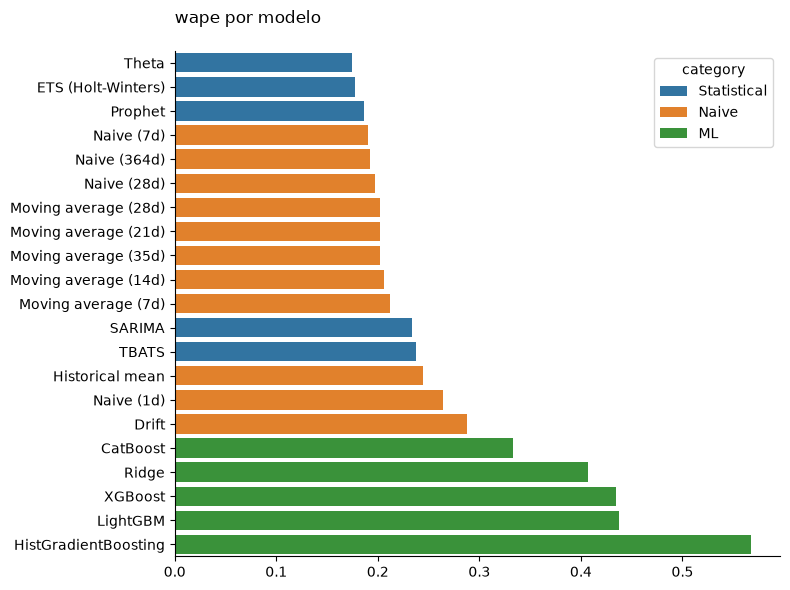

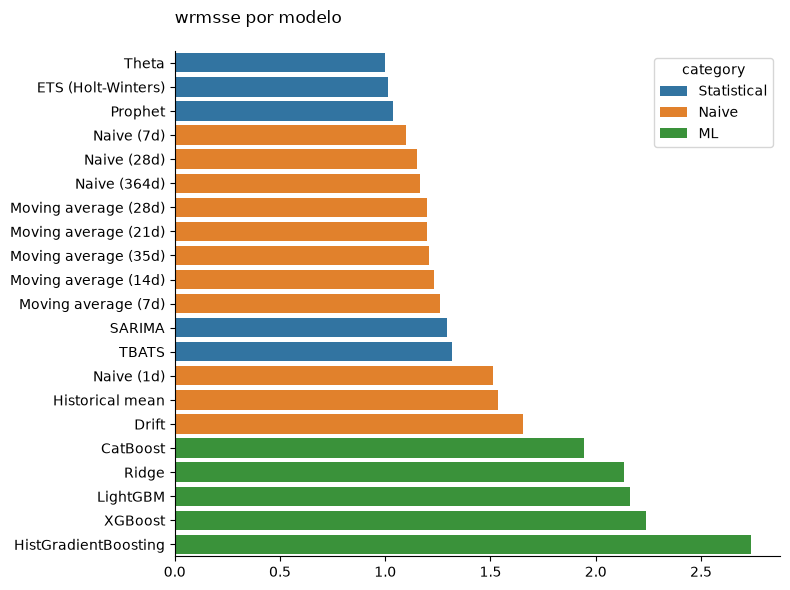

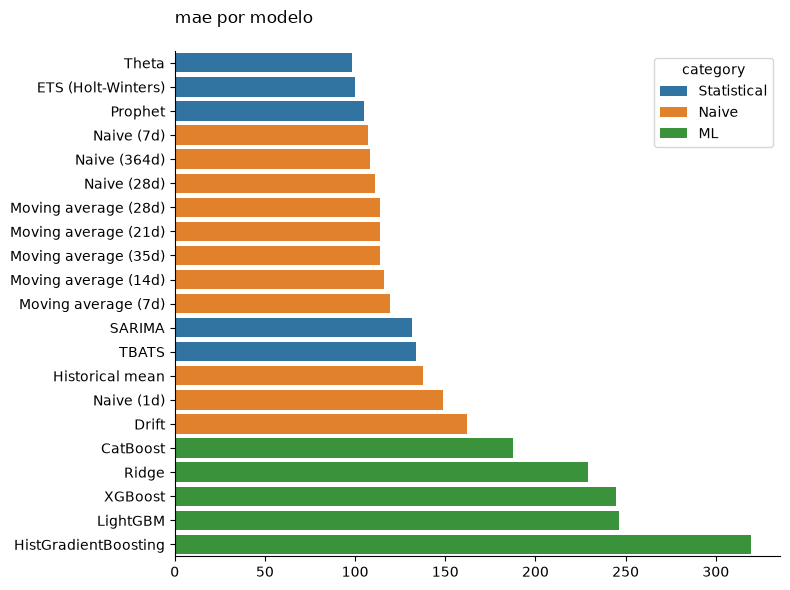

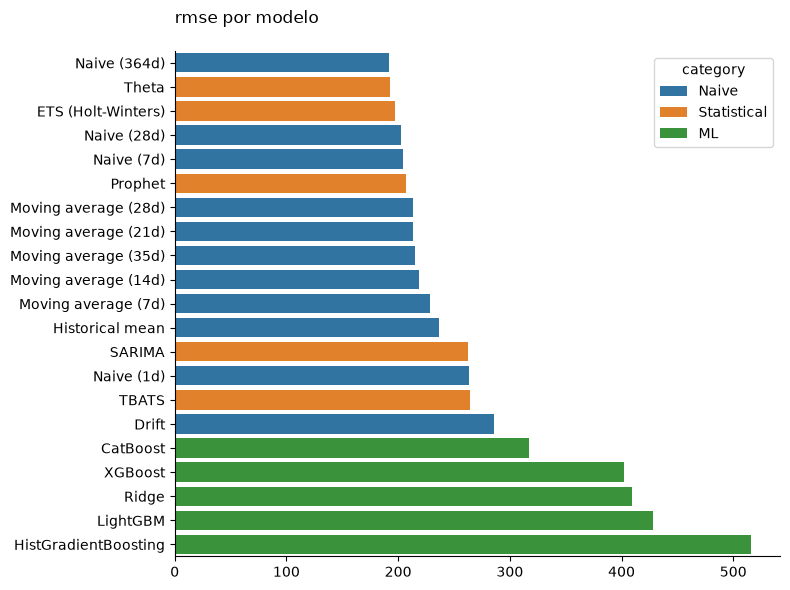

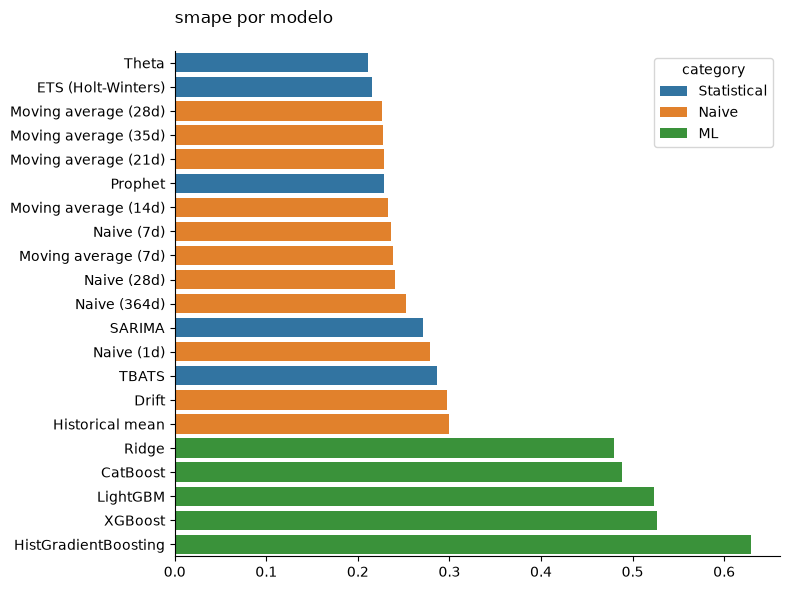

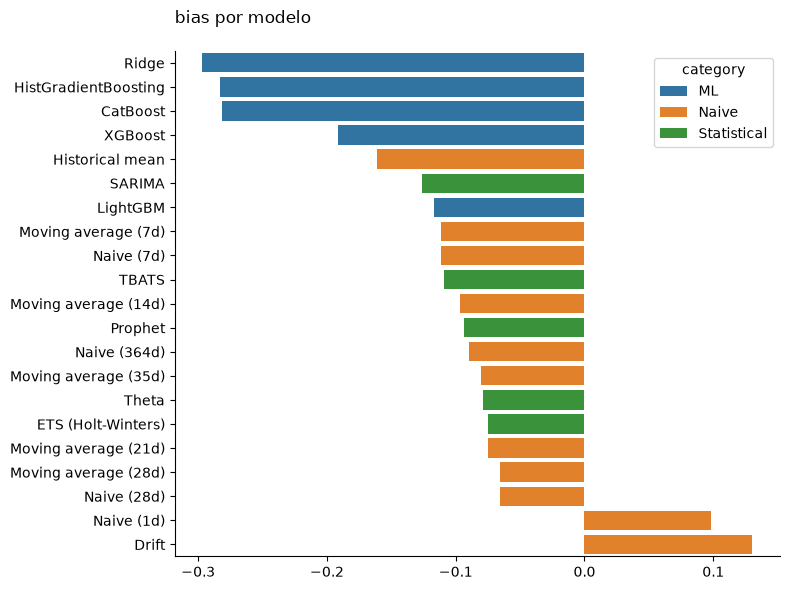

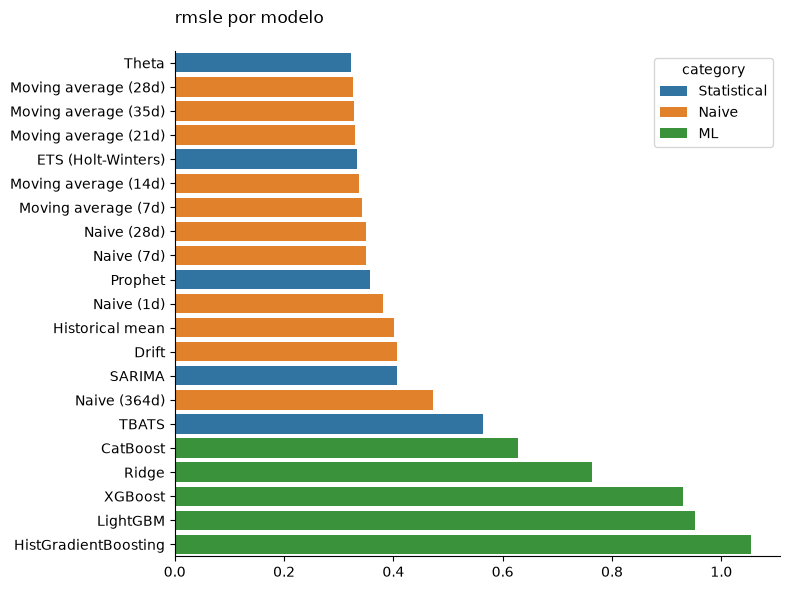

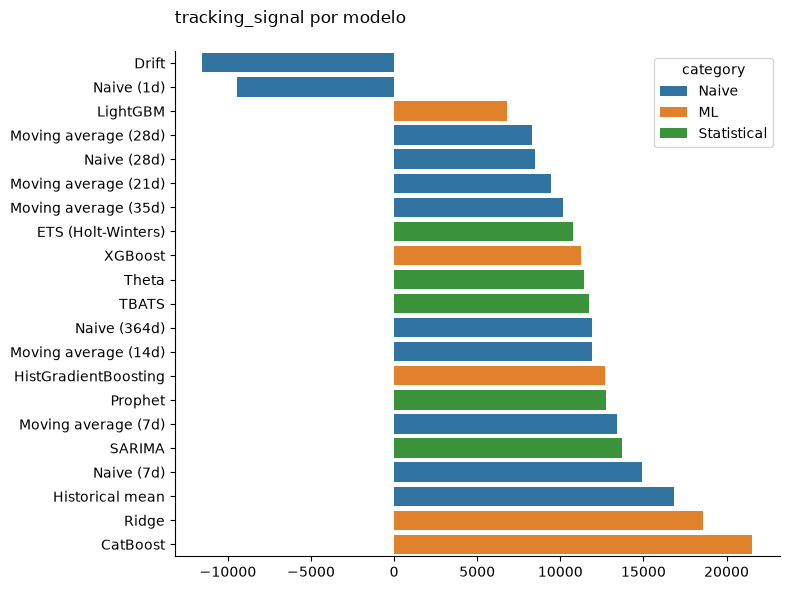

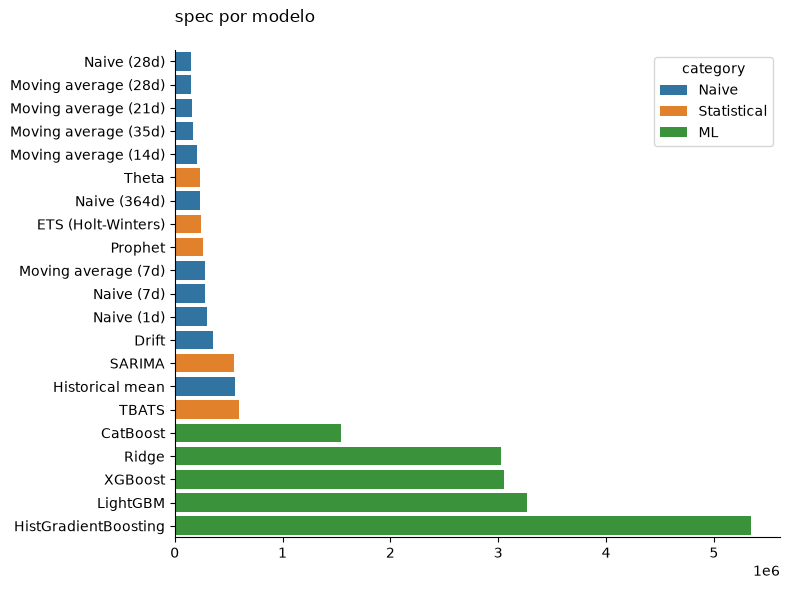

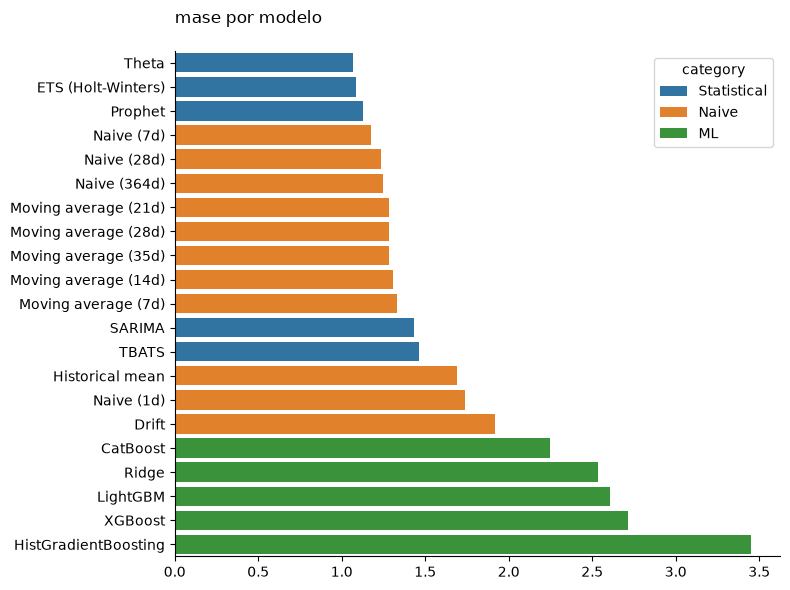

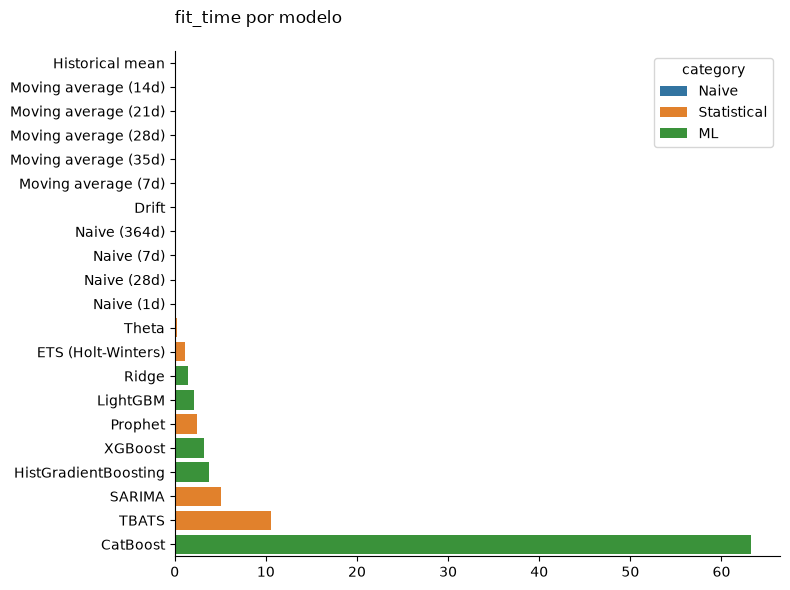

In [31]:
for col in ['wape', 'wrmsse', 'mae', 'rmse', 'smape', 'bias', 'rmsle', 'tracking_signal', 'spec', 'mase', 'fit_time']:
    plot_barh_by_model(results_df, hue="category", x=col, y="model", title=f"{col} por modelo")

# Selección de features

El resto del notebook usa LightGBM (velocidad, soporte nativo de categóricas, compatible con SHAP), así que la selección se hace sobre `lgbm_model`. Se comparan dos criterios de importancia (gain del árbol vs. permutation importance sobre validación) y luego se aplica una eliminación hacia atrás (backward elimination): se van descartando las features menos importantes mientras el WRMSSE de validación no empeore más allá de una tolerancia.

## Importancia por ganancia (gain)

In [32]:
importance_gain = (
    pd.Series(lgbm_model.booster_.feature_importance(importance_type="gain"), index=FEATURES)
    .sort_values(ascending=False)
)
importance_gain.head(20)

rolling_mean_lag1_window_size7    9.075511e+10
lag1                              5.200339e+10
lag7                              2.489063e+10
lag28                             2.284036e+10
lag21                             2.828795e+09
lag14                             2.153732e+09
lag91                             1.456992e+09
snap                              8.263369e+08
dayofweek                         6.931295e+08
lag35                             3.377538e+08
is_store_closed                   3.321091e+08
lag56                             3.129116e+08
lag182                            3.113326e+08
price_change                      2.866988e+08
event_name_1                      2.564867e+08
lag364                            2.185699e+08
dow_sin                           1.744332e+08
dept_id                           1.652894e+08
store_id                          1.644673e+08
price_vs_mean                     1.590161e+08
dtype: float64

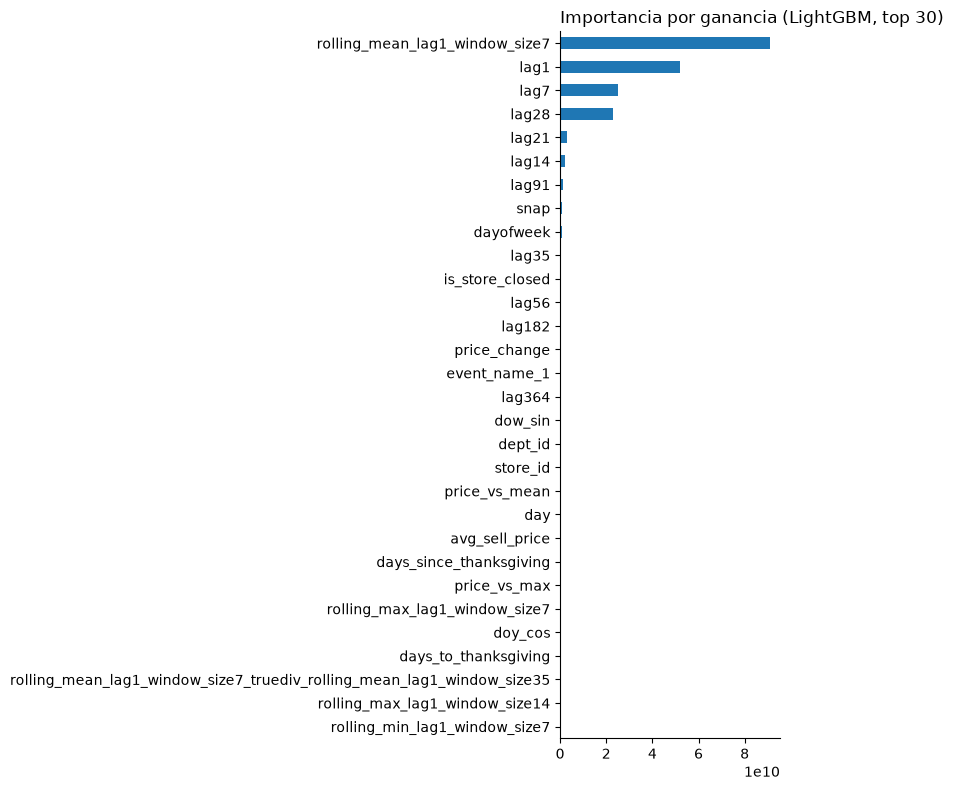

In [33]:
fig, ax = plt.subplots(figsize=(8, 8))
importance_gain.head(30).sort_values().plot.barh(ax=ax)
ax.set_title("Importancia por ganancia (LightGBM, top 30)", loc="left")
sns.despine()
plt.tight_layout()
plt.show()

## Permutation importance

El gain puede sobreestimar features de alta cardinalidad o muy usadas para splits sin aportar demasiado al error final. La permutation importance mide directamente cuánto empeora el RMSE en validación al mezclar (shuffle) cada columna, así que es un criterio más fiel al desempeño real del modelo.

In [34]:
from src.modeling import compute_permutation_importance

importance_perm = compute_permutation_importance(
    lgbm_model, X_valid, y_valid, FEATURES,
    sample_size=300_000, n_repeats=5, random_state=RANDOM_STATE,
)
importance_perm.head(20)

dept_id                            58.179754
lag28                              35.182045
lag21                              19.920263
lag7                               16.991842
lag182                             11.127101
lag364                             10.925889
lag14                               7.022347
lag91                               6.996565
rolling_mean_lag28_window_size7     5.545547
lag56                               4.671079
store_id                            3.792824
lag1                                3.589547
dayofweek                           2.146064
dow_sin                             1.312659
rolling_mean_lag1_window_size7      1.129848
snap                                1.121650
lag2                                0.707354
rolling_std_lag28_window_size7      0.657777
rolling_min_lag91_window_size28     0.650870
event_name_1                        0.591978
dtype: float64

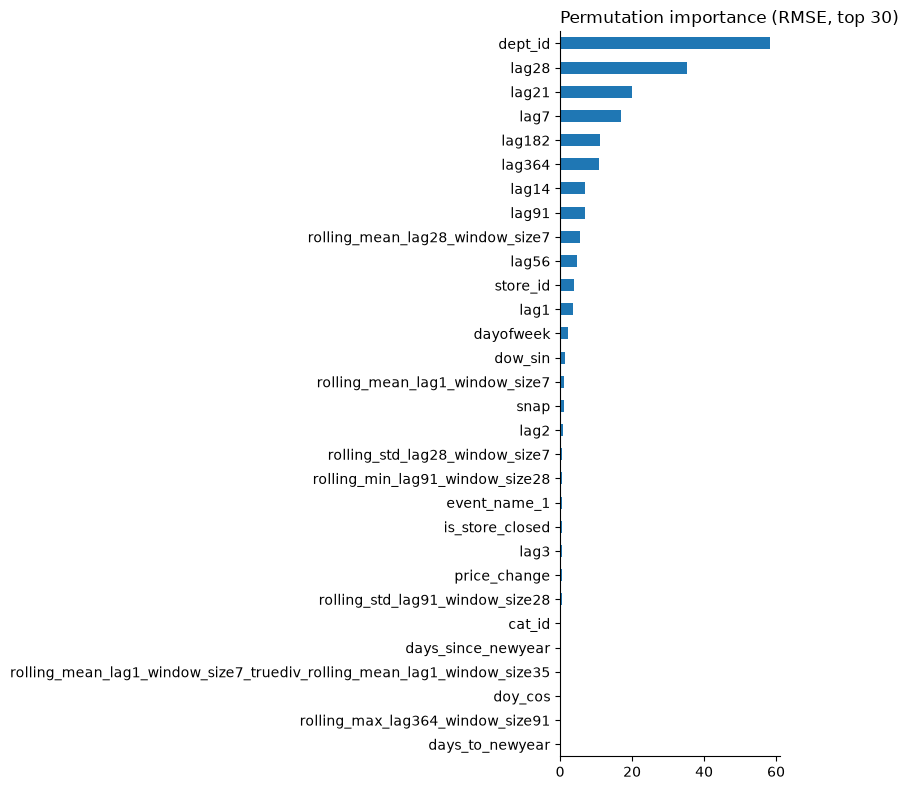

In [35]:
fig, ax = plt.subplots(figsize=(8, 8))
importance_perm.head(30).sort_values().plot.barh(ax=ax)
ax.set_title("Permutation importance (RMSE, top 30)", loc="left")
sns.despine()
plt.tight_layout()
plt.show()

## Eliminación hacia atrás (backward elimination)

Se parte del ranking de permutation importance (de menor a mayor) y se intenta eliminar cada feature: si reentrenar sin ella no empeora el WRMSSE de validación más allá de `TOLERANCE`, se descarta definitivamente.

In [ ]:
from src.modeling import backward_feature_selection

selected_features, final_wrmsse, log_df = backward_feature_selection(
    X_train, y_train, X_valid, train, valid,
    FEATURES, CATEGORICAL_FEATURES, importance_perm,
    tolerance=0.0, random_state=RANDOM_STATE,
)

2026-08-23 20:39:53.181 | INFO     | src.modeling.feature_selection:backward_feature_selection:80 - Baseline (121 features): WRMSSE=2.1647
2026-08-23 20:39:55.982 | WARNING  | src.modeling.feature_selection:backward_feature_selection:96 - ELIMINADA: 'price_vs_mean' -> 120 features | WRMSSE=2.0235
2026-08-23 20:39:58.765 | SUCCESS  | src.modeling.feature_selection:backward_feature_selection:98 - mantiene: 'lag35' | WRMSSE empeoraría a 2.0388
2026-08-23 20:40:01.391 | WARNING  | src.modeling.feature_selection:backward_feature_selection:96 - ELIMINADA: 'rolling_max_lag28_window_size28' -> 119 features | WRMSSE=2.0200
2026-08-23 20:40:04.097 | SUCCESS  | src.modeling.feature_selection:backward_feature_selection:98 - mantiene: 'price_vs_max' | WRMSSE empeoraría a 2.0796
2026-08-23 20:40:06.545 | WARNING  | src.modeling.feature_selection:backward_feature_selection:96 - ELIMINADA: 'rolling_mean_lag365_window_size28' -> 118 features | WRMSSE=2.0189
2026-08-23 20:40:08.297 | WARNING  | src.mode

In [ ]:
baseline_wrmsse = log_df.loc[log_df["removed"].isna(), "wrmsse"].iloc[0]

trajectory = log_df[log_df["accepted"]].sort_values("n_features", ascending=False)
baseline_wrmsse = trajectory["wrmsse"].iloc[0]

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(trajectory, x="n_features", y="wrmsse", marker="o", ax=ax)
ax.invert_xaxis()
ax.axhline(baseline_wrmsse, color="grey", linestyle="--", linewidth=1, label="baseline (todas las features)")
ax.set_title("WRMSSE de validación durante la eliminación hacia atrás", loc="left")
ax.set_xlabel("Cantidad de features")
ax.set_ylabel("WRMSSE")
ax.legend(loc="upper right")
sns.despine()
plt.tight_layout()
plt.show()

## Features seleccionadas

Se fija `FEATURES` (y las variables derivadas `X_train`/`X_valid`/`X_test`/`CATEGORICAL_FEATURES`/`NUMERICAL_FEATURES`) al subconjunto seleccionado, para que el resto del notebook (modelo simple, SHAP, tuning con Optuna, modelo final) entrene sobre las features filtradas.

In [ ]:
print(f"Features descartadas ({len(FEATURES) - len(selected_features)}): "
      f"{sorted(set(FEATURES) - set(selected_features))}")

FEATURES = selected_features
CATEGORICAL_FEATURES = [c for c in CATEGORICAL_FEATURES if c in FEATURES]
NUMERICAL_FEATURES = [c for c in NUMERICAL_FEATURES if c in FEATURES]

X_train = X_train[FEATURES]
X_valid = X_valid[FEATURES]
X_test = X_test[FEATURES]

print(f"Features finales: {len(FEATURES)} ({len(CATEGORICAL_FEATURES)} categóricas)")

# Modelo con variables seleccionadas

In [ ]:
from src.evaluation import make_wrmsse_metric

wrmsse_metric = make_wrmsse_metric(train, valid)

In [ ]:
model = LGBMRegressor(
    objective="rmse",
)

t0 = time.perf_counter()
model.fit(
    X_train,
    y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric=[wrmsse_metric,],
    callbacks=[
        lgb.early_stopping(100, first_metric_only=True),
        lgb.log_evaluation(10),
    ],
)
fit_time = time.perf_counter() - t0

evaluate_model("LightGBM (selected features)", model.predict(X_valid), fit_time=fit_time, category="ML")

## Explicación modelo

In [ ]:
import shap

explainer = shap.TreeExplainer(model)

X_shap = X_test.sample(n=min(30_000, len(X_test)), random_state=RANDOM_STATE)
shap_values = explainer.shap_values(X_shap)
shap_df = pd.DataFrame(shap_values, columns=X_shap.columns, index=X_shap.index)

importance_df = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values).mean(axis=0),
}).sort_values("mean_abs_shap", ascending=False)

print(importance_df)

In [ ]:
shap.summary_plot(shap_values, X_shap, plot_type="bar")

In [ ]:
shap.summary_plot(shap_values, X_shap)

# Predicciones

In [ ]:
from src.evaluation import plot_forecast
from src.evaluation import analizar_prediccion as _analizar_prediccion

def analizar_prediccion(agg_id, date=None, max_display=10):
    return _analizar_prediccion(
        test, X_test, df_pred, TARGET, agg_id,
        date=date, max_display=max_display, explainer=explainer,
    )

In [ ]:
from src.evaluation.metrics import build_predictions_report

metrics_test, df_pred = build_predictions_report(train, test, y_test, model.predict(X_test), target_col=TARGET)

print(f"Test WAPE: {metrics_test['wape']:.2%}")
print(f"Test WRMSSE: {metrics_test['wrmsse']:.4f}")

# Modelo optimizado

In [ ]:
import optuna
from optuna.integration import LightGBMPruningCallback

In [ ]:
def objective(trial):
    params = dict(
        objective=OBJECTIVE,
        learning_rate=trial.suggest_float("learning_rate", 0.03, 0.15, log=True),
        n_estimators=1500,
        num_leaves=trial.suggest_int("num_leaves", 31, 255),
        max_depth=trial.suggest_int("max_depth", 5, 10),
        min_child_samples=trial.suggest_int("min_child_samples", 20, 200),
        subsample=trial.suggest_float("subsample", 0.6, 1.0),
        subsample_freq=1,
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.6, 1.0),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 5, log=True),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-3, 5, log=True),
        random_state=42,
        n_jobs=-1,
        verbosity=-1,
    )

    if OBJECTIVE == "tweedie":
        params["tweedie_variance_power"] = trial.suggest_float(
            "tweedie_variance_power", 1.1, 1.9
        )

    eval_metric = "tweedie" if OBJECTIVE == "tweedie" else "rmse"

    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train,
        y_train,
        eval_set=[(X_valid, y_valid)],
        eval_metric=eval_metric,
        categorical_feature=CATEGORICAL_FEATURES,
        callbacks=[
            lgb.early_stopping(30, first_metric_only=True, verbose=False),
            LightGBMPruningCallback(trial, eval_metric),
        ],
    )

    y_pred = model.predict(X_valid, num_iteration=model.best_iteration_)
    _, final_wrmsse, _ = wrmsse_metric(y_valid, y_pred)
    return final_wrmsse

In [ ]:
study = optuna.create_study(
    study_name=f"study_{LEVEL}", 
    direction="minimize",
    storage="sqlite:///../artifacts/optuna_study.db",
    load_if_exists=True,
    sampler=optuna.samplers.TPESampler(
        seed=42,
    ),
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=10, n_startup_trials=5),
)

study.optimize(
    objective,
    n_trials=1_000,
    timeout=60 * 10,
    show_progress_bar=True,
)

best_trial = study.best_trial
print(f"Mejor WRMSSE: {best_trial.value:.4f}")
print("Mejores hiperparámetros:", best_trial.params)

# Modelo final

In [ ]:
model_params = best_trial.params

final_model = lgb.LGBMRegressor(
    objective=OBJECTIVE,
    n_estimators=3_000,
    random_state=42,
    n_jobs=-1,
    verbosity=-1,
    subsample_freq=1,
    **model_params,
)

t0 = time.perf_counter()
final_model.fit(
    X_train, y_train,
    eval_set=[(X_valid, y_valid)],
    eval_metric=wrmsse_metric,
    categorical_feature=CATEGORICAL_FEATURES,
    callbacks=[
        lgb.early_stopping(100, first_metric_only=True),
        lgb.log_evaluation(10),
    ],
)
fit_time = time.perf_counter() - t0

evaluate_model("LightGBM (selected features | Optuna)", final_model.predict(X_valid), fit_time=fit_time, category="ML")

## Resultados finales

In [ ]:
results_df = pd.DataFrame(model_results).sort_values("wrmsse")
metrics_test_final, df_pred = build_predictions_report(train, test, y_test, final_model.predict(X_test), target_col=TARGET)

print(f"Test WAPE: {metrics_test_final['wape']:.2%}")
print(f"Test WRMSSE: {metrics_test_final['wrmsse']:.4f}")

# Exportar

In [ ]:
import joblib

feature_importance = (
    pd.Series(final_model.booster_.feature_importance(importance_type="gain"), index=FEATURES)
    .sort_values(ascending=False)
)

# No se guardan df/X_train/y_train/X_valid/y_valid/valid: reconstruibles desde el
# parquet en data/datasets/ + este mismo notebook, y notebooks/03_predictions.ipynb
# no los usa -- guardarlos solo triplicaba el tamaño del artifact (y el pico de RAM
# al armarlo) sin necesidad, justo lo que hace fallar por memoria al nivel 12.
artifact = {
    # modelo y datos de trabajo
    "level": LEVEL,
    "objective": OBJECTIVE,
    "model": final_model,
    "model_params": model_params,
    "metrics_results": results_df,
    "X_test": X_test,
    "y_test": y_test,
    "train": train,
    "test": test,
    # features y columnas
    "features": FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "numerical_features": NUMERICAL_FEATURES,
    "id_cols": ID_COLS,
    "leaky_cols": LEAKY_COLS,
    "target": TARGET,
    "feature_importance": feature_importance,
    # predicciones y métricas del modelo final (test)
    #"df_pred": df_pred,
    #"df_metrics": df_metrics,
    # comparación de todos los modelos probados (validación)
    "model_results": model_results,
    "results_df": results_df,
    #"series_metrics_valid": series_metrics_df,
    # metadatos
    "wape_valid": model_results[-1]["wape"],
    "wrmsse_valid": model_results[-1]["wrmsse"],
    "wape_test": metrics_test_final["wape"],
    "wrmsse_test": metrics_test_final["wrmsse"],
    "train_start": str(first_date.date()),
    "valid_start": str(valid_start.date()),
    "test_start": str(test_start.date()),
}

artifact_path = f"../artifacts/models/{LEVEL}_{TARGET}_artifact.pkl"
joblib.dump(artifact, artifact_path)
print(f"Artifact guardado en {artifact_path}")